# Laboratorio #3

* Josue Say - 228801
* Flavio Galán - 22386

## Repositorio

- [Enlace](https://github.com/JosueSay/labs-ds/tree/main/lab3)
- [Data](https://drive.google.com/drive/folders/1DZaL352Xo1kNSpZjXH-HmXbgpbyhrx6E?usp=drive_link)

## Análisis exploratorio

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
from collections import Counter
from PIL import Image

### Constantes

In [2]:
BASE_DIR = "./data_original/train"
IMAGE_DIR = "./images"
REPORT_DIR = "./reports"
MODALITIES = ['m0', 'm1', 'm2', 'm3', 'm4']
DO_EA = False

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

reportPath = os.path.join(REPORT_DIR, "analisis_exploratorio.txt")

### Generación de reportes

In [3]:
def writeToReport(text, printAlso=True):
    with open(reportPath, "a", encoding="utf-8") as f:
        f.write(text + "\n")
    if printAlso:
        print(text)

In [4]:
def resetReport():
    with open(reportPath, "w", encoding="utf-8") as f:
        f.write("ANÁLISIS EXPLORATORIO DATASET IMAGENES\n\n")

In [5]:
def checkImageResolution(modality='m0'):
    path = os.path.join(BASE_DIR, modality)
    imgPath = os.path.join(path, random.choice(os.listdir(path)))
    img = Image.open(imgPath)
    size = img.size
    writeToReport(f"Ejemplo de resolución de imágen de {modality}: {size}")
    return size

In [6]:
def countDigitsPerModality():
    writeToReport("Distribución de imágenes de dígitos por modalidad:\n")
    for modality in MODALITIES:
        path = os.path.join(BASE_DIR, modality)
        files = os.listdir(path)
        digits = [f.split('.')[-2] for f in files]
        count = Counter(digits)
        writeToReport(f"{modality}:")
        for d in sorted(count):
            writeToReport(f"  Dígito {d}: {count[d]} imágenes")
        writeToReport("")

In [7]:
def countImagesPerModality():
    writeToReport("Total de imágenes por modo:\n")
    for modality in MODALITIES:
        path = os.path.join(BASE_DIR, modality)
        total = len(os.listdir(path))
        writeToReport(f"{modality}: {total} imágenes")
    writeToReport("")

In [8]:
def showDigitExamplesPerModality(digit="5", saveImage=False):
    plt.figure(figsize=(15, 6))
    for i, modality in enumerate(MODALITIES):
        modalityPath = os.path.join(BASE_DIR, modality)
        digitImages = [f for f in os.listdir(modalityPath) if f.endswith(f".{digit}.png")]
        if not digitImages:
            continue

        imgFile = random.choice(digitImages)
        imgPath = os.path.join(modalityPath, imgFile)
        img = mpimg.imread(imgPath)

        plt.subplot(1, 5, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"{modality} - {digit}")
        plt.axis("off")

    plt.suptitle(f"Ejemplo del dígito '{digit}' en las modalidades")
    plt.tight_layout()

    if saveImage:
        savePath = os.path.join(IMAGE_DIR, f"digit_{digit}_modalities.png")
        plt.savefig(savePath)
        writeToReport(f"Image saved to: {savePath}")

    plt.show()

In [9]:
if DO_EA:
    resetReport()
    showDigitExamplesPerModality(digit="2", saveImage=True)
    checkImageResolution(modality="m0")
    countImagesPerModality()
    countDigitsPerModality()

## Avances

### Librerías

In [10]:
import os
import random
import matplotlib.pyplot as plt
from matplotlib.image import imread
import keras
from keras.utils import image_dataset_from_directory

2025-08-02 09:51:46.773680: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [11]:
numberToName = {
    0: "zero",
    1: "one",
    2: "two",
    3: "three",
    4: "four",
    5: "five",
    6: "six",
    7: "seven",
    8: "eight",
    9: "nine",
}

## Explorando los Datos

In [12]:
def showRandomExamples(folder="data/train", samples=9):
    """
    Muestra imágenes aleatorias de distintas clases desde la carpeta dada.
    """
    plt.figure(figsize=(12, 6))
    for i in range(samples):
        number = random.randint(0, 9)
        subfolder = numberToName[number]
        filename = f'{folder}/{subfolder}/m{random.randint(1,4)}-0.{number}.png'
        try:
            image = imread(filename)
            plt.subplot(3, 3, i + 1)
            plt.imshow(image, cmap="gray")
            plt.title(f"{subfolder}")
            plt.axis("off")
        except FileNotFoundError:
            print(f"Imagen no encontrada: {filename}")
    plt.tight_layout()
    plt.show()

In [13]:
def loadImageDataset(dataDir="data/train", batchSize=32, imageSize=(28, 28), shuffle=True):
    """
    Carga el dataset desde carpetas organizadas por clase usando Keras.
    Retorna un objeto tf.data.Dataset listo para entrenamiento.
    """
    dataset = image_dataset_from_directory(
        dataDir,
        labels='inferred',
        batch_size=batchSize,
        image_size=imageSize,
        shuffle=shuffle
    )
    return dataset

In [14]:
def loadImageDatasetWithSplit(dataDir="data/train", imageSize=(28, 28), batchSize=32, valSplit=0.2, seed=123):
    train_ds = image_dataset_from_directory(
        dataDir,
        validation_split=valSplit,
        subset="training",
        seed=seed,
        image_size=imageSize,
        batch_size=batchSize
    )
    val_ds = image_dataset_from_directory(
        dataDir,
        validation_split=valSplit,
        subset="validation",
        seed=seed,
        image_size=imageSize,
        batch_size=batchSize
    )
    return train_ds, val_ds

Esta función carga un conjunto de imágenes desde `data/train` y lo divide automáticamente en dos subconjuntos:

- trains_ds
- val_ds


| Parámetro   | Descripción                                                                                        |
| ----------- | -------------------------------------------------------------------------------------------------- |
| `dataDir`   | Ruta a la carpeta raíz donde están las imágenes organizadas por clase. Por defecto: `"data/train"` |
| `imageSize` | Tamaño al que se redimensionan todas las imágenes. Por defecto: `(28, 28)`                         |
| `batchSize` | Cantidad de imágenes que se agrupan en un lote. Por defecto: `32`                                  |
| `valSplit`  | Porcentaje del conjunto que se reservará como validación. Por defecto: `0.2` (20%)                 |
| `seed`      | Semilla aleatoria que asegura que la división sea reproducible.                                    |

In [15]:
def normalizeDataset(dataset):
    normalization_layer = Rescaling(1./255)
    return dataset.map(lambda x, y: (normalization_layer(x), y))

In [16]:
# showRandomExamples()

Como se puede ver las imágenes tienen una gran variedad de fondos, pero en tamaño son todas iguales por lo que no hay que aplicarles transformaciones de resolución.

## Entrenamiento

### Librerias

In [17]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
import matplotlib.pyplot as plt
import os
from tensorflow.keras.layers import Rescaling

### Constantes

In [18]:
train_ds, val_ds = loadImageDatasetWithSplit()
train_ds = normalizeDataset(train_ds)
val_ds = normalizeDataset(val_ds)

Found 300000 files belonging to 10 classes.
Using 240000 files for training.
Found 300000 files belonging to 10 classes.
Using 60000 files for validation.


### Módelos

In [19]:
def buildSimpleCNN(inputShape=(28, 28, 3), numClasses=10):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=inputShape),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(numClasses, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

Esto crea un modelo **de red neuronal convolucional (CNN)** simple:

* `Conv2D`: una capa convolucional que extrae características como bordes y formas locales.
* `MaxPooling2D`: reduce la resolución manteniendo la información importante.
* `Flatten`: convierte la matriz en un vector para pasarla a la red densa.
* `Dense`: capas densas (fully connected) que aprenden relaciones entre las características extraídas.
* `softmax`: convierte la salida en probabilidades sobre 10 clases (números del 0 al 9).

In [20]:
def buildVggStyleCNN(inputShape=(28, 28, 3), numClasses=10, dropoutRate=0.25):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=inputShape),
        MaxPooling2D((2,2)),
        Dropout(dropoutRate),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Dropout(dropoutRate),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(numClasses, activation='softmax')
    ])
    model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [21]:
def buildSimpleDenseModel(inputShape=(28, 28, 3), numClasses=10):
    model = Sequential([
        Flatten(input_shape=inputShape),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(numClasses, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [22]:
def trainAndEvaluate(model, trainData, valData, epochs=5, modelName="Model"):
    history = model.fit(trainData, validation_data=valData, epochs=epochs, verbose=1)
    loss, acc = model.evaluate(valData, verbose=0)
    print(f"{modelName} Accuracy: {acc*100:.2f}%")

    # Graficar
    plt.figure(figsize=(12, 4))

    # Pérdida
    plt.subplot(1, 2, 1)
    plt.title("Loss")
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Exactitud
    plt.subplot(1, 2, 2)
    plt.title("Accuracy")
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.suptitle(modelName)
    plt.tight_layout()
    plt.show()

    return acc

### Hiperparámetros

In [23]:
epochs = 5
dropoutOptions = [0.2, 0.3]

### Ejecutando modelos

In [24]:
results = []

Epoch 1/5


/nix/store/niyqgsn9ncy7dd9p1yj60dgjp46wlnrd-python3-3.12.11-env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7500/7500 ━━━━━━━━━━━━━━━━━━━━ 58s 8ms/step - accuracy: 0.8559 - loss: 0.4683 - val_accuracy: 0.9456 - val_loss: 0.1751
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 57s 8ms/step - accuracy: 0.9538 - loss: 0.1489 - val_accuracy: 0.9602 - val_loss: 0.1269
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 58s 8ms/step - accuracy: 0.9666 - loss: 0.1048 - val_accuracy: 0.9630 - val_loss: 0.1241
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 57s 8ms/step - accuracy: 0.9746 - loss: 0.0780 - val_accuracy: 0.9636 - val_loss: 0.1327
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 59s 8ms/step - accuracy: 0.9792 - loss: 0.0617 - val_accuracy: 0.9608 - val_loss: 0.1563
Simple CNN Accuracy: 96.08%


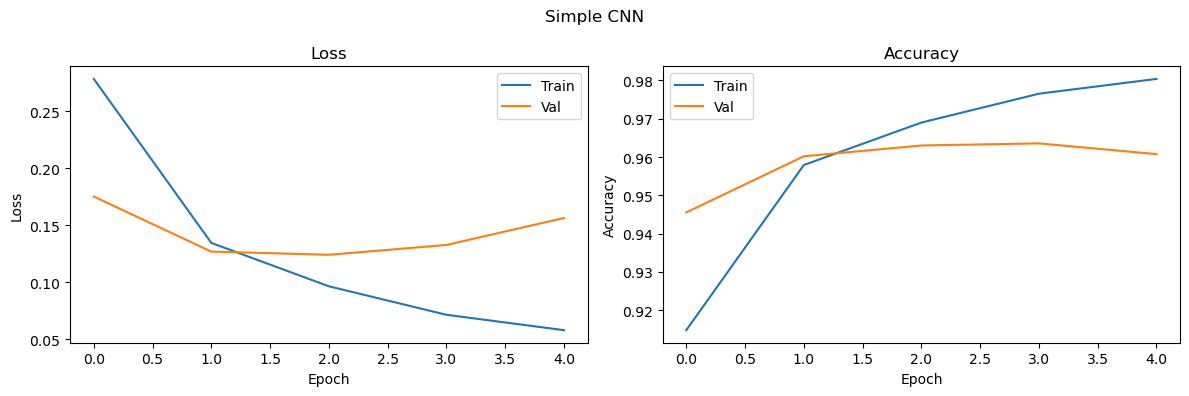

In [25]:
# CNN
model1 = buildSimpleCNN()
acc1 = trainAndEvaluate(model1, train_ds, val_ds, epochs=epochs, modelName="Simple CNN")
results.append(("Simple CNN", acc1))

| Aspecto       | Resultado                                                                  |
| ------------- | -------------------------------------------------------------------------- |
| Entrenamiento | Aprende rápidamente y sigue mejorando                                      |
| Validación    | Mejora al inicio, luego se estabiliza                                      |
| Sobreajuste   | Comienza a aparecer levemente después del epoch 3-4                        |

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - accuracy: 0.8351 - loss: 0.5014 - val_accuracy: 0.9718 - val_loss: 0.0935
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 65s 9ms/step - accuracy: 0.9626 - loss: 0.1172 - val_accuracy: 0.9783 - val_loss: 0.0732
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - accuracy: 0.9711 - loss: 0.0894 - val_accuracy: 0.9825 - val_loss: 0.0544
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 65s 9ms/step - accuracy: 0.9765 - loss: 0.0733 - val_accuracy: 0.9834 - val_loss: 0.0518
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - accuracy: 0.9797 - loss: 0.0631 - val_accuracy: 0.9857 - val_loss: 0.0451
VGG Style CNN (Dropout=0.2) Accuracy: 98.57%


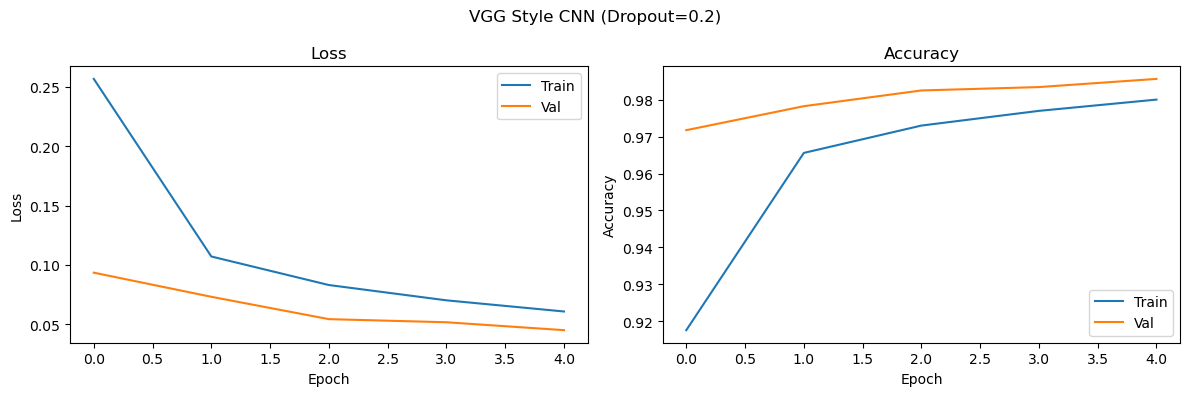

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - accuracy: 0.8240 - loss: 0.5304 - val_accuracy: 0.9665 - val_loss: 0.1081
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - accuracy: 0.9547 - loss: 0.1409 - val_accuracy: 0.9789 - val_loss: 0.0701
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - accuracy: 0.9644 - loss: 0.1103 - val_accuracy: 0.9768 - val_loss: 0.0736
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 67s 9ms/step - accuracy: 0.9689 - loss: 0.0975 - val_accuracy: 0.9823 - val_loss: 0.0559
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - accuracy: 0.9716 - loss: 0.0884 - val_accuracy: 0.9825 - val_loss: 0.0552
VGG Style CNN (Dropout=0.3) Accuracy: 98.25%


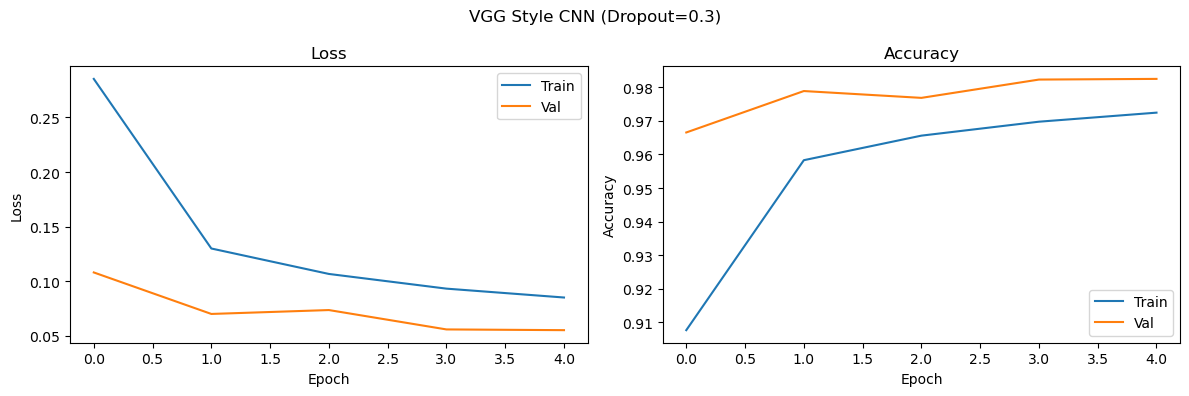

In [26]:
# VGG style con tuning
for dropout in dropoutOptions:
    modelName = f"VGG Style CNN (Dropout={dropout})"
    model2 = buildVggStyleCNN(dropoutRate=dropout)
    acc2 = trainAndEvaluate(model2, train_ds, val_ds, epochs=epochs, modelName=modelName)
    results.append((modelName, acc2))

Epoch 1/5


/nix/store/niyqgsn9ncy7dd9p1yj60dgjp46wlnrd-python3-3.12.11-env/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7500/7500 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.5723 - loss: 1.2629 - val_accuracy: 0.7570 - val_loss: 0.7543
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.7678 - loss: 0.7194 - val_accuracy: 0.7854 - val_loss: 0.6831
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.7979 - loss: 0.6302 - val_accuracy: 0.8004 - val_loss: 0.6263
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.8112 - loss: 0.5835 - val_accuracy: 0.8030 - val_loss: 0.6243
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.8246 - loss: 0.5468 - val_accuracy: 0.8049 - val_loss: 0.6097
Simple Dense NN Accuracy: 80.49%


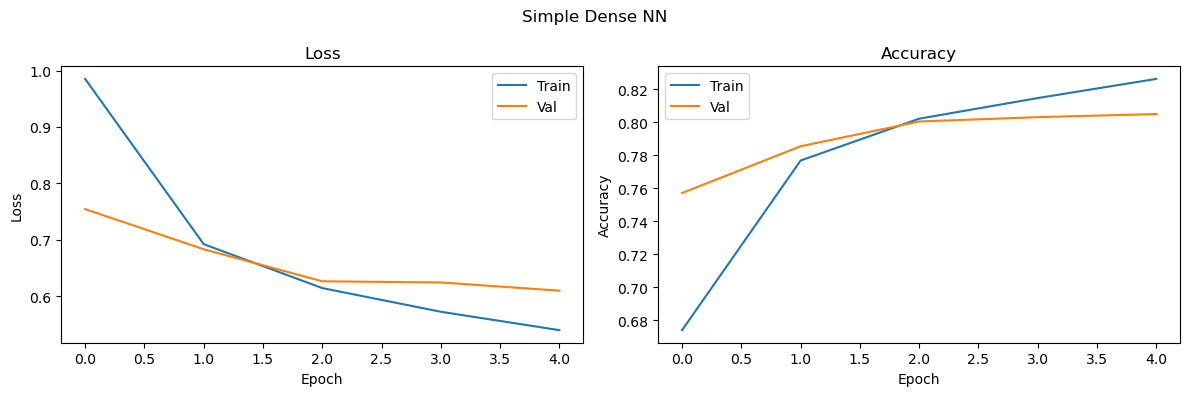

In [27]:
# DL simple
model3 = buildSimpleDenseModel()
acc3 = trainAndEvaluate(model3, train_ds, val_ds, epochs=epochs, modelName="Simple Dense NN")
results.append(("Simple Dense NN", acc3))

In [28]:
print("--- Resumen resultados ---")
for name, acc in results:
    print(f"{name}: {acc*100:.2f}%")

bestModel = max(results, key=lambda x: x[1])
print(f"\nMejor modelo: {bestModel[0]} con precisión {bestModel[1]*100:.2f}%")

--- Resumen resultados ---
Simple CNN: 96.08%
VGG Style CNN (Dropout=0.2): 98.57%
VGG Style CNN (Dropout=0.3): 98.25%
Simple Dense NN: 80.49%

Mejor modelo: VGG Style CNN (Dropout=0.2) con precisión 98.57%


## Modelo SVM

Para utilizar el model SVM primero tenemos que transformar la data a vectores que entienda SVC. Para esto utilizaremos un modelo VGG16, una CNN que nos permite extraer las características principales de una imagen pequeña y luego extraemos todas las características de todo el dataset de pruebas.

Este proceso demora mucho tiempo, por lo tanto guardamos los datos usando pickle para que futuros coldstarts sean más eficientes.

In [55]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import pickle

# 1. Load the Keras Image Dataset
# Assuming your images are in 'path/to/your/dataset' with subdirectories for classes
image_size = (28*3, 28*3)
batch_size = 32


def resize_images(image, label):
    # Resize image from 28x28 to 84x84
    resized_image = tf.image.resize(image, [28*3, 28*3])
    return resized_image, label

print("Resizing images...")
scaled_train_ds = train_ds.map(resize_images)
print("Done!")

# 2. Feature Extraction using a pre-trained VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
base_model.trainable = False # Freeze the base model layers

feature_extractor = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D() # Flatten the output features
])

features = []
labels = []

if os.path.exists("modelsData/svm_features") and os.path.exists("modelsData/svm_labels"):
    with open("modelsData/svm_features", "rb") as file:
        features = pickle.load(file)
    with open("modelsData/svm_labels", "rb") as file:
        labels = pickle.load(file)
else:
    print("Extracting features...")
    for i, (images, batch_labels) in enumerate(scaled_train_ds):
        print(f"Doing {i} of {len(scaled_train_ds)}")
        extracted_features = feature_extractor(images)
        features.append(extracted_features.numpy())
        labels.append(batch_labels.numpy())
    print("Done!")
    
    with open("modelsData/svm_features", "wb") as file:
        pickle.dump(features, file)
    with open("modelsData/svm_labels", "wb") as file:
        pickle.dump(labels, file)

Resizing images...
Done!


Una vez se tienen las características extraídas por VGG16, podemos proceder a entrenar el modelo objetivo SVM:

In [51]:
X = np.concatenate(features, axis=0)
y = np.concatenate(labels, axis=0)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the SVM Model
print("Training SVM Model...")
svm_model = SVC(kernel='rbf', C=1.0, verbose=True, max_iter=epochs * 50) # Example with RBF kernel
svm_model.fit(X_train, y_train)
print("Done!")

# 5. Evaluate the SVM Model
print("Scoring Model...")
accuracy = svm_model.score(X_test, y_test)
print(f"SVM Accuracy: {accuracy}")

Training SVM Model...
[LibSVM]WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -492.000700, rho = -0.651679
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -488.519610, rho = -0.353357
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -491.609016, rho = -0.460150
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -484.053038, rho = -0.388087
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -488.497726, rho = -0.529484
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -484.185594, rho = -0.505494
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 250
obj = -487.898723, rho = -0.922073
nSV = 500, nBSV = 500
WARN: libsvm Solver reached max_iter
optimization finished, #iter =

/nix/store/niyqgsn9ncy7dd9p1yj60dgjp46wlnrd-python3-3.12.11-env/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=250).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM Accuracy: 0.3627708333333333


In [52]:
results.append(("SVM Model", accuracy))

In [53]:
print("--- Resumen resultados ---")
for name, acc in results:
    print(f"{name}: {acc*100:.2f}%")

bestModel = max(results, key=lambda x: x[1])
print(f"\nMejor modelo: {bestModel[0]} con precisión {bestModel[1]*100:.2f}%")

--- Resumen resultados ---
Simple CNN: 96.08%
VGG Style CNN (Dropout=0.2): 98.57%
VGG Style CNN (Dropout=0.3): 98.25%
Simple Dense NN: 80.49%
SVM Model: 29.96%
SVM Model: 34.41%
SVM Model: 36.28%

Mejor modelo: VGG Style CNN (Dropout=0.2) con precisión 98.57%
